# Time-of-Day Clustering — K-Means Analysis

**Dataset:** `data/clean/final_dataset_full_clean.csv`  
**Goal:** Discover natural diurnal price and load regimes using time-of-day features.

Electricity markets have strong within-day structure: overnight off-peak, morning ramp-up, midday solar suppression, and evening demand peak. This clustering analysis checks whether those regimes emerge unsupervised from the data.

Features used:
- `hour_sin`, `hour_cos` — cyclical encoding of hour (preserves 23→0 continuity)
- `price` — day-ahead electricity price (EUR/MWh)
- `total_load` — actual electricity consumption (MW)
- `generation_forecast` — day-ahead renewable generation forecast (MW)
- `shortwave_radiation` — solar irradiance (W/m²), peaks at midday

## 1. Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('../data/clean/final_dataset_full_clean.csv', parse_dates=['time'])
df = df.set_index('time').sort_index()

print(f'Rows: {len(df):,}  ({df.index.min().date()} — {df.index.max().date()})')
print(f'Columns: {list(df.columns)}')

Rows: 96,133  (2015-01-04 — 2025-12-31)
Columns: ['price', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'temperature_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation', 'total_load', 'generation_forecast']


## 2. Select Features and Scale

In [3]:
TOD_FEATURES = [
    'hour_sin',
    'hour_cos',
    'price',
    'total_load',
    'generation_forecast',
    'shortwave_radiation',
]

X = df[TOD_FEATURES].dropna().copy()
hour_labels = df.loc[X.index, 'hour']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Clustering matrix: {X_scaled.shape}')
print('\nFeature statistics (original scale):')
print(X.describe().round(2))

Clustering matrix: (96133, 6)

Feature statistics (original scale):
       hour_sin  hour_cos     price  total_load  generation_forecast  \
count  96133.00  96133.00  96133.00    96133.00             96133.00   
mean      -0.00     -0.00     76.69    12171.60              1113.42   
std        0.71      0.71     78.85     2478.65              1046.70   
min       -1.00     -1.00   -500.00      478.77                 0.76   
25%       -0.71     -0.71     34.14    10593.32               337.25   
50%        0.00     -0.00     49.71    11919.66               779.50   
75%        0.71      0.71     92.27    13818.33              1575.50   
max        1.00      1.00    872.96    21475.69              6435.00   

       shortwave_radiation  
count             96133.00  
mean                129.16  
std                 196.02  
min                   0.00  
25%                   0.00  
50%                   5.80  
75%                 203.40  
max                 886.20  


## 3. Elbow Method — Choose k

For diurnal patterns we might expect fewer than 4 clusters (e.g. off-peak, ramp, peak, solar-suppressed midday) — the elbow plot will guide the choice.

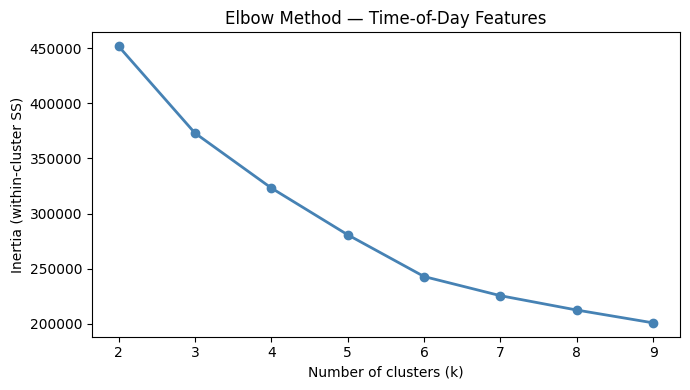

In [4]:
inertias = []
k_range  = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia (within-cluster SS)')
ax.set_title('Elbow Method — Time-of-Day Features')
plt.tight_layout()
plt.show()

## 4. Fit K-Means (k = 4)

Four clusters map naturally to four diurnal regimes commonly observed in electricity markets:
- **Off-peak night** — low load, low price
- **Morning ramp** — rising load, rising price
- **Midday solar** — high radiation, load plateau, price suppression from solar
- **Evening peak** — highest load, highest price

In [5]:
K = 4
CLUSTER_COLORS = ['#2c7bb6', '#d7191c', '#fdae61', '#1a9641']
CLUSTER_NAMES  = ['Off-peak night', 'Morning ramp', 'Midday solar', 'Evening peak']

km = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

X_result = X.copy()
X_result['cluster'] = labels
X_result['hour']    = hour_labels.values

# Centroids in original units
centroids = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=TOD_FEATURES,
).round(2)
centroids.index.name = 'Cluster'
print('Cluster centroids (original scale):')
print(centroids[['price', 'total_load', 'generation_forecast', 'shortwave_radiation']])

Cluster centroids (original scale):
          price  total_load  generation_forecast  shortwave_radiation
Cluster                                                              
0         69.05    14165.59              1270.66                55.65
1         59.18    11181.89              1165.10                15.13
2         53.30    11015.25               856.66               428.34
3        317.72    11914.01               921.20                89.90


## 5. Hour Distribution per Cluster

If the clustering has captured diurnal regimes, each cluster should dominate a specific block of hours.

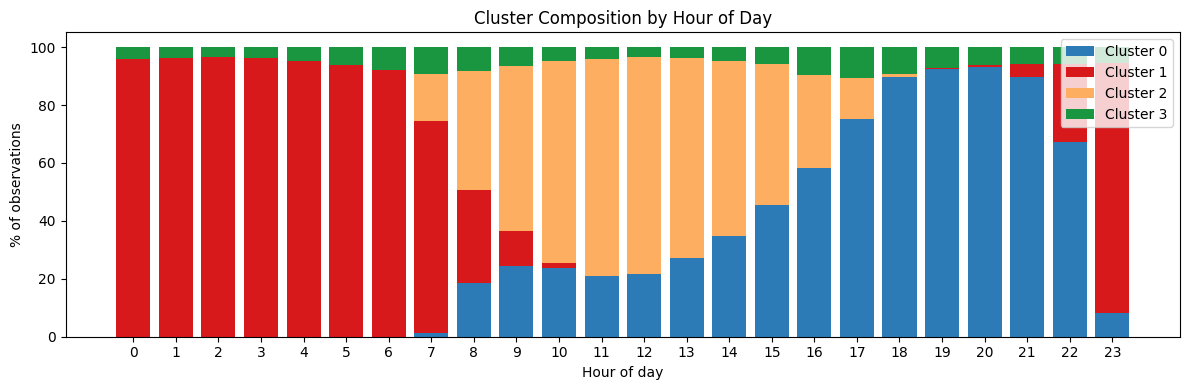

In [6]:
hour_cluster = pd.crosstab(
    X_result['hour'],
    X_result['cluster'],
    normalize='index',
).mul(100).round(1)
hour_cluster.columns = [f'C{c}' for c in hour_cluster.columns]

fig, ax = plt.subplots(figsize=(12, 4))
bottom = np.zeros(24)
for i, col in enumerate(hour_cluster.columns):
    ax.bar(hour_cluster.index, hour_cluster[col], bottom=bottom,
           color=CLUSTER_COLORS[i], label=f'Cluster {i}', width=0.8)
    bottom += hour_cluster[col].values

ax.set_xlabel('Hour of day')
ax.set_ylabel('% of observations')
ax.set_title('Cluster Composition by Hour of Day')
ax.set_xticks(range(24))
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 6. Mean Price and Load Profile per Cluster

Average price and load across the 24-hour day, coloured by cluster, shows how the clusters track the diurnal economic cycle.

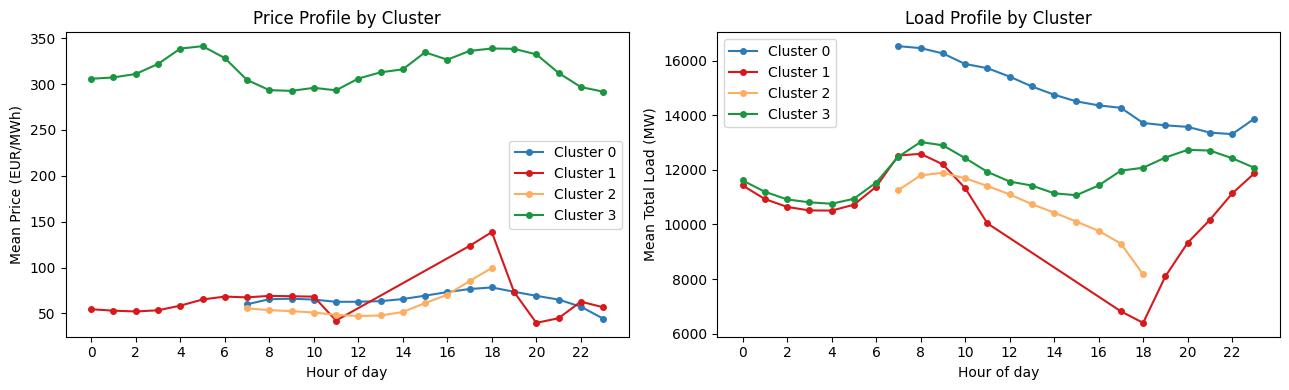

In [7]:
hourly = X_result.groupby(['hour', 'cluster'])[['price', 'total_load']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for c in range(K):
    sub = hourly[hourly['cluster'] == c].sort_values('hour')
    axes[0].plot(sub['hour'], sub['price'],     color=CLUSTER_COLORS[c],
                 marker='o', markersize=4, label=f'Cluster {c}')
    axes[1].plot(sub['hour'], sub['total_load'], color=CLUSTER_COLORS[c],
                 marker='o', markersize=4, label=f'Cluster {c}')

axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Mean Price (EUR/MWh)')
axes[0].set_title('Price Profile by Cluster')
axes[0].legend()

axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Mean Total Load (MW)')
axes[1].set_title('Load Profile by Cluster')
axes[1].legend()

for ax in axes:
    ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

## 7. Price Distribution per Cluster

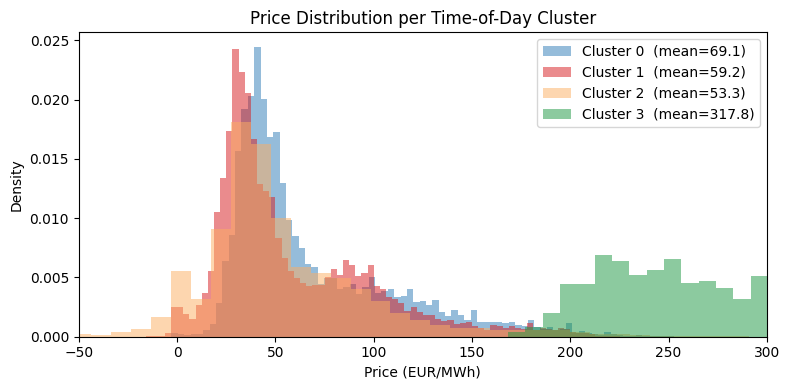

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

for c in range(K):
    prices = X_result.loc[X_result['cluster'] == c, 'price']
    ax.hist(prices, bins=80, alpha=0.5, color=CLUSTER_COLORS[c],
            label=f'Cluster {c}  (mean={prices.mean():.1f})', density=True)

ax.set_xlabel('Price (EUR/MWh)')
ax.set_ylabel('Density')
ax.set_title('Price Distribution per Time-of-Day Cluster')
ax.legend()
ax.set_xlim(-50, 300)
plt.tight_layout()
plt.show()

## 8. Interpretation

- **Hour concentration**: Each cluster should map predominantly to a contiguous block of hours — if it does, the algorithm has recovered the diurnal market cycle without supervision.
- **Solar suppression**: A midday cluster with elevated `shortwave_radiation` and relatively lower price than the morning/evening clusters would confirm the "merit-order effect" — solar generation pushes cheaper electricity onto the grid and suppresses prices at noon.
- **Evening peak**: The cluster associated with hours 17–20 is expected to show the highest mean price and load.
- **Implication for forecasting**: The `hour_sin`/`hour_cos` features, `total_load`, and `generation_forecast` all carry strong diurnal signal. Their inclusion in the forecasting model helps it distinguish an 8am prediction from a 3am one even given the same recent price history.